In [29]:
from pyspark.sql import SparkSession
from pyspark.sql import functions as F
import os
from pyspark.sql import Window

In [30]:
spark = SparkSession.builder \
    .appName("VenchiDataLoading") \
    .getOrCreate()

## Read Data

In [31]:
# 1. perform cd..
current_path = os.getcwd()
parent_path = os.path.dirname(current_path)

# 2. Construct absolute paths using os.path.join 
# This automatically handles slashes correctly for Mac/Linux/Windows
accounts_path = os.path.join(parent_path, 'data', 'accounts.parquet')
interactions_path = os.path.join(parent_path, 'data', 'interactions.parquet')
products_path = os.path.join(parent_path, 'data', 'products.txt')
sales_path = os.path.join(parent_path, 'data', 'sales.parquet')

# 3. Read the data in Spark
# Spark will now receive the full, absolute path (e.g., /Users/Name/Project/data/accounts.parquet)
accounts_df = spark.read.parquet(accounts_path)
accounts_df.printSchema()
interactions_df = spark.read.parquet(interactions_path)
interactions_df.printSchema()
sales_df = spark.read.parquet(sales_path)
sales_df.printSchema()
products_df = spark.read.csv(products_path, sep='\t', header=True, inferSchema=True)
products_df.printSchema()

root
 |-- account_id: string (nullable = true)
 |-- hct: long (nullable = true)
 |-- staff: long (nullable = true)
 |-- turnover_m_usd: long (nullable = true)
 |-- brand_loyalty: long (nullable = true)
 |-- timestamp: string (nullable = true)

root
 |-- interaction_id: string (nullable = true)
 |-- channel: string (nullable = true)
 |-- duration_mins: long (nullable = true)
 |-- response: string (nullable = true)
 |-- topic: string (nullable = true)
 |-- date: string (nullable = true)
 |-- account_id: string (nullable = true)
 |-- product_id: string (nullable = true)

root
 |-- sale_id: string (nullable = true)
 |-- date: string (nullable = true)
 |-- account_id: string (nullable = true)
 |-- product_id: string (nullable = true)

root
 |-- product_id: string (nullable = true)
 |-- maturity: string (nullable = true)
 |-- price: integer (nullable = true)
 |-- category: string (nullable = true)
 |-- patent_id: string (nullable = true)



### Data Cleaning

In [32]:
accounts_clean = accounts_df.filter(F.col("account_id").isNotNull())

interactions_clean = interactions_df.filter(F.col("account_id").isNotNull()) \
    .withColumn("topic_clean", F.lower(F.trim(F.col("topic")))) \
    .withColumn("channel_clean", F.lower(F.trim(F.col("channel")))) \
    .withColumn("response_clean", F.lower(F.trim(F.col("response"))))

sales_clean = sales_df.filter(F.col("account_id").isNotNull())
products_clean = products_df.filter(F.col("product_id").isNotNull())

In [33]:
accounts_clean.groupBy("account_id").count().orderBy('count').filter(F.col("count") > 1).toPandas()

,account_id,count
0,d1022401b7eec8871ae15060675defd8,2
1,0ffe7466d9271fdea80561895e646212,2
2,edba0822938758da14ea7bf2115f33a5,2
3,c8937bf01102a4c633d99c2789776ab2,2
4,fb8a2c3a0a50442354fe11ae6b9f9d21,2
...,...,...
2131,fd242bcbfb732223d528a501ccfcbc7d,3
2132,01459f98eb6004b1acec895aad76ed64,3
2133,04c6f523dbbf07accf50428134daf4d5,3
2134,0368996b1a19e1aa1034363420a95fe5,3


In [34]:
# Order by timestamp DESCENDING (newest first)
latest_window = Window.partitionBy("account_id").orderBy(F.col("timestamp").desc())

# Keep only the newest record per account
deduplicated_accounts = (
    accounts_clean
    .withColumn("row_num", F.row_number().over(latest_window))
    .filter(F.col("row_num") == 1)
    .drop("row_num") # Drop the helper column when done
)

In [35]:
accounts_clean = deduplicated_accounts

In [36]:
accounts_clean.groupBy("account_id").count().orderBy('count').filter(F.col("count") > 1).toPandas()

,account_id,count


In [37]:
sales_clean.groupBy("sale_id").count().orderBy('count').filter(F.col("count") > 1).toPandas()

,sale_id,count


In [38]:
interactions_clean.groupBy("interaction_id").count().orderBy('count').filter(F.col("count") > 1).toPandas()

,interaction_id,count


In [39]:
products_clean.groupBy("product_id").count().orderBy('count').filter(F.col("count") > 1).toPandas()

,product_id,count


## Task 1

### KPI 1: Total Revenue Generated

In [40]:
sales_with_price = sales_clean.join(products_clean, on="product_id", how="left")

In [41]:
# Aggregate revenue per customer
kpi_revenue = sales_with_price.groupBy("account_id").agg(
    F.sum("price").alias("total_revenue")
)

In [42]:
kpi_revenue.show(10)

+--------------------+-------------+
|          account_id|total_revenue|
+--------------------+-------------+
|e1672d506568deedf...|       121980|
|cb04cb651869ca904...|        56680|
|a054955a13c04e9aa...|       106884|
|115d1256179d8ca02...|        89245|
|ccaf873af5b6fdd3b...|        93540|
|2aca7152120b6433f...|        39077|
|caf1c34f21405ceb6...|        68992|
|79f393197ee0b3251...|        45490|
|0ff82ad074e663021...|        63555|
|21fc105190774346e...|        63909|
+--------------------+-------------+
only showing top 10 rows


### KPI 2: Number of sales interactions in the last 6 months

In [43]:
max_date_row = interactions_clean.select(F.max("date").alias("latest_date")).collect()[0]
latest_date = max_date_row["latest_date"]
print(f"Latest interaction date: {latest_date}")

Latest interaction date: 2021-02-05T00:00:00.000Z


In [44]:
sales_interactions_6m = interactions_clean.filter(
    (F.col("date") >= F.date_sub(F.lit(latest_date), 180))
)
sales_interactions_6m.show(10)

+--------------------+------------+-------------+--------+-------------------+--------------------+--------------------+--------------------+-------------------+-------------+--------------+
|      interaction_id|     channel|duration_mins|response|              topic|                date|          account_id|          product_id|        topic_clean|channel_clean|response_clean|
+--------------------+------------+-------------+--------+-------------------+--------------------+--------------------+--------------------+-------------------+-------------+--------------+
|9e8a83833a5a5dafb...|       email|            6|positive|against competition|2020-10-17T00:00:...|544feaa1526ef94f1...|2a38ce238f4b3a52b...|against competition|        email|      positive|
|17f65a62b55523036...|face to face|           82|   mixed|  available finance|2021-01-24T00:00:...|f63ebf8ff4a382c2e...|0eed3f6963570b036...|  available finance| face to face|         mixed|
|909f3a6eca8fbf6b7...|face to face|          

In [45]:
# Aggregate count per customer
kpi_recent_sales_interactions = sales_interactions_6m.groupBy("account_id").agg(
    F.count("interaction_id").alias("sales_interactions_last_6m")
)

<Axes: >

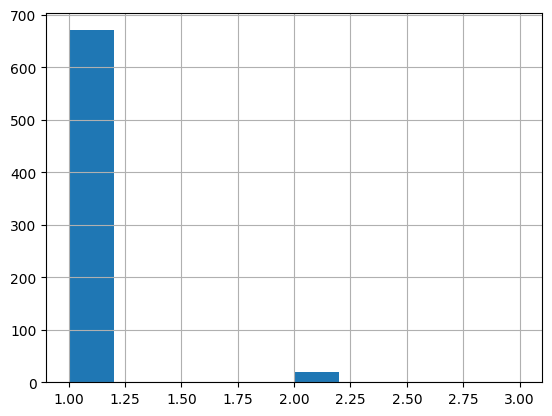

In [74]:
kpi_recent_sales_interactions.toPandas().sales_interactions_last_6m.hist()

### KPI 3 Number of Products that the client bought

In [58]:
kpi_distinct_products = sales_with_price.groupBy("account_id").agg(
    F.countDistinct("product_id").alias("n_distinct_products") 
)

<Axes: >

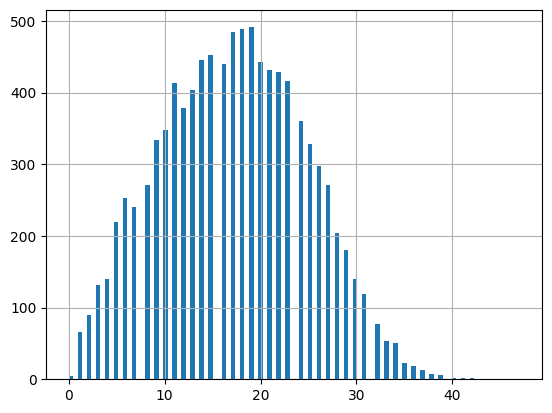

In [72]:
kpi_distinct_products.toPandas().n_distinct_products.hist(bins=100)

In [75]:
# Old not used
kpi_distinct_category= sales_with_price.groupBy("account_id").agg(
    F.countDistinct("category").alias("distinct_categories") 
)

<Axes: >

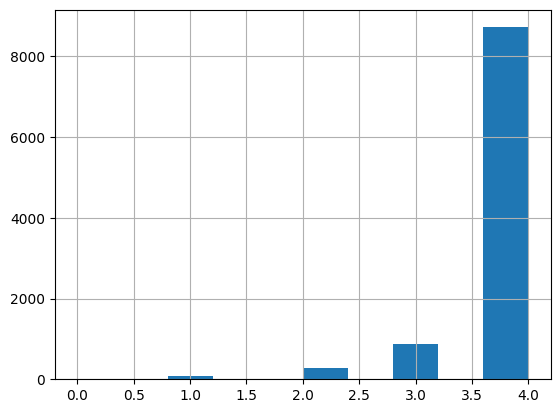

In [69]:
kpi_distinct_category.toPandas().distinct_categories.hist()

### KPI: Average interaction for client

In [76]:
kpi_avg_duration = interactions_clean.groupBy("account_id").agg(
    F.round(F.avg("duration_mins"), 2).alias("avg_interaction_duration_mins")
)

In [77]:
kpi_avg_duration.show(5)

+--------------------+-----------------------------+
|          account_id|avg_interaction_duration_mins|
+--------------------+-----------------------------+
|285fffa8d29a9f9b2...|                         14.0|
|26b8c340d56a7e3bb...|                        102.5|
|ae9e95dc1fb78abec...|                         70.5|
|98f62e8b624d99682...|                        121.0|
|fdf8a784a1d444a52...|                       132.67|
+--------------------+-----------------------------+
only showing top 5 rows


<Axes: >

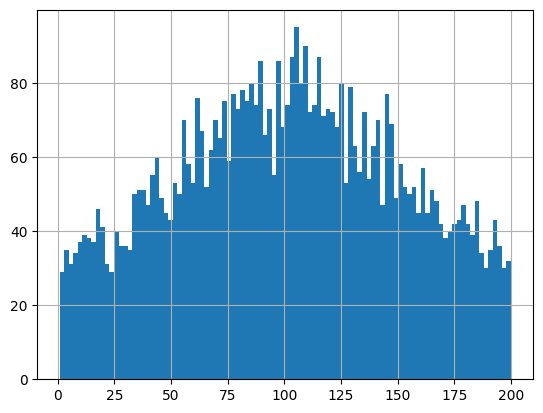

In [79]:
kpi_avg_duration.toPandas().avg_interaction_duration_mins.hist(bins=100)

## TASK 2

### Putting Data Together

In [80]:
analytical_dataset = accounts_clean \
    .join(kpi_revenue, on="account_id", how="left") \
    .join(kpi_recent_sales_interactions, on="account_id", how="left") \
    .join(kpi_distinct_products, on="account_id", how="left") \
    .join(kpi_avg_duration, on="account_id", how="left")
shape = (analytical_dataset.count(), len(analytical_dataset.columns))
print(shape)

(10000, 10)


In [81]:
analytical_dataset.columns

['account_id',
 'hct',
 'staff',
 'turnover_m_usd',
 'brand_loyalty',
 'timestamp',
 'total_revenue',
 'sales_interactions_last_6m',
 'n_distinct_products',
 'avg_interaction_duration_mins']

In [82]:
analytical_dataset = analytical_dataset.fillna({
    "total_revenue": 0,
    "sales_interactions_last_6m": 0,
    "n_distinct_products": 0,
    "avg_interaction_duration_mins": 0
})

<Axes: >

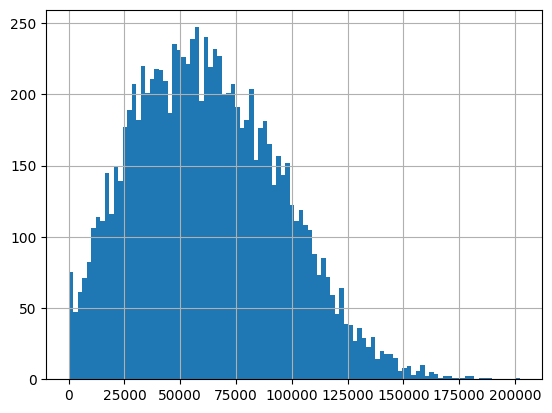

In [86]:
analytical_dataset.toPandas()['total_revenue'].hist(bins=100)

In [88]:
analytical_dataset.show(10)

+--------------------+---+-----+--------------+-------------+-------------------+-------------+--------------------------+-------------------+-----------------------------+
|          account_id|hct|staff|turnover_m_usd|brand_loyalty|          timestamp|total_revenue|sales_interactions_last_6m|n_distinct_products|avg_interaction_duration_mins|
+--------------------+---+-----+--------------+-------------+-------------------+-------------+--------------------------+-------------------+-----------------------------+
|00119d8d5d812849b...| 30|   11|            11|            9|2020-09-03 09:42:12|        27536|                         0|                 10|                          0.0|
|0021b64fc2553dcee...| 68|    9|            83|           11|2020-09-03 09:42:12|        95847|                         0|                 24|                          0.0|
|0027ea1a4498ac70a...| 86|   22|            41|            6|2020-09-03 09:42:12|        10701|                         0|             

### Developing the model

In [89]:
from pyspark.ml.feature import VectorAssembler, StandardScaler
from pyspark.ml.clustering import KMeans
from pyspark.ml.evaluation import ClusteringEvaluator

In [93]:
# 1. PREPARE DATA FOR MACHINE LEARNING
ml_data = analytical_dataset.fillna(0)

# Define the features we want our model to learn from.
# We mix firmographics (turnover) with our engineered behavioral KPIs.
feature_cols = [
    "turnover_m_usd", 
    "brand_loyalty", 
    "total_revenue", 
    "sales_interactions_last_6m", 
    "n_distinct_products", 
    "avg_interaction_duration_mins"
]

# VectorAssembler combines our individual feature columns into a single vector column called 'features'
assembler = VectorAssembler(inputCols=feature_cols, outputCol="raw_features")
assembled_data = assembler.transform(ml_data)

# StandardScaler normalizes the features so they have a mean of 0 and std dev of 1.
# This prevents large numerical values (like revenue) from dominating the K-Means distance calculations.
scaler = StandardScaler(inputCol="raw_features", outputCol="scaled_features", withStd=True, withMean=True)
scaler_model = scaler.fit(assembled_data)
scaled_data = scaler_model.transform(assembled_data)

# 2. DETERMINE THE NUMBER OF CLUSTERS (k)
# We iterate through potential cluster sizes (2 to 5) and calculate the Silhouette Score.
# A score closer to 1 indicates well-separated, dense clusters.

evaluator = ClusteringEvaluator(predictionCol="prediction", featuresCol="scaled_features", metricName="silhouette")
best_k = 2
best_score = -1

print("Evaluating cluster sizes...")
for k in range(2, 6):
    kmeans = KMeans(featuresCol="scaled_features", k=k, seed=42)
    model = kmeans.fit(scaled_data)
    predictions = model.transform(scaled_data)
    score = evaluator.evaluate(predictions)
    print(f"Silhouette Score for k={k}: {score:.4f}")
    
    if score > best_score:
        best_score = score
        best_k = k

print(f"\nSelected optimal number of clusters: {best_k} (based on highest Silhouette Score)")


Evaluating cluster sizes...
Silhouette Score for k=2: 0.4552
Silhouette Score for k=3: 0.5104
Silhouette Score for k=4: 0.4460
Silhouette Score for k=5: 0.4443

Selected optimal number of clusters: 3 (based on highest Silhouette Score)


In [92]:
# 3. TRAIN FINAL MODEL & ASSIGN SEGMENTS

# Train the final model using the best K
final_kmeans = KMeans(featuresCol="scaled_features", k=best_k, seed=42)
final_model = final_kmeans.fit(scaled_data)

# Apply the model to our dataset to generate the 'prediction' column (the segment ID)
enriched_data = final_model.transform(scaled_data)

# Rename 'prediction' to 'customer_segment' for business clarity
enriched_data = enriched_data.withColumnRenamed("prediction", "customer_segment")


# ==========================================
# 4. PROFILE THE SEGMENTS
# ==========================================
# Calculate the average values for our KPIs per segment to understand who these customers are.
segment_profiles = enriched_data.groupBy("customer_segment").agg(
    F.count("account_id").alias("customer_count"),
    F.round(F.avg("turnover_m_usd"), 2).alias("avg_turnover"),
    F.round(F.avg("brand_loyalty"), 2).alias("avg_loyalty"),
    F.round(F.avg("total_revenue"), 2).alias("avg_revenue"),
    F.round(F.avg("sales_interactions_last_6m"), 2).alias("avg_recent_interactions"),
    F.round(F.avg("n_distinct_products"), 2).alias("avg_distinct_products")
).orderBy("customer_segment")

print("\n--- Segment Profiles ---")
segment_profiles.show()


--- Segment Profiles ---
+----------------+--------------+------------+-----------+-----------+-----------------------+---------------------+
|customer_segment|customer_count|avg_turnover|avg_loyalty|avg_revenue|avg_recent_interactions|avg_distinct_products|
+----------------+--------------+------------+-----------+-----------+-----------------------+---------------------+
|               0|          4545|       72.77|        6.1|   88353.34|                    0.0|                23.31|
|               1|          4764|        28.8|        4.2|   37308.48|                    0.0|                11.08|
|               2|           691|       59.11|       4.51|   66873.27|                   1.03|                18.23|
+----------------+--------------+------------+-----------+-----------+-----------------------+---------------------+

